In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### -> Upload the dataset

In [2]:
data=pd.read_csv('insurance.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
data.sample()

,age,sex,bmi,children,smoker,region,charges
643,23,female,34.96,3,no,northwest,4466.6214


In [6]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [7]:
data.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [8]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(1)

In [10]:
data=data.drop_duplicates()
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [12]:
data.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
data.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1337.000000,1337,1337.000000,1337.000000,1337,1337,1337.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,675,NaN,NaN,1063,364,NaN
mean,39.222139,NaN,30.663452,1.095737,NaN,NaN,13279.121487
std,14.044333,NaN,6.100468,1.205571,NaN,NaN,12110.359656
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.290000,0.000000,NaN,NaN,4746.344000
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9386.161300
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16657.717450


## -> Exploratory Data Analysis

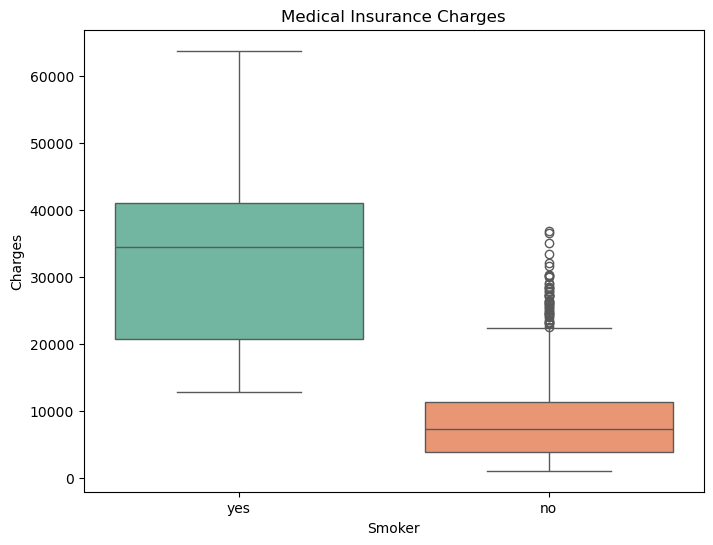

In [14]:
#  Question: Does smoking significantly increase insurance charges?
plt.figure(figsize=(8,6))
sns.boxplot(x='smoker', y='charges', data=data, palette='Set2')
plt.title('Medical Insurance Charges')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

<Axes: xlabel='age', ylabel='charges'>

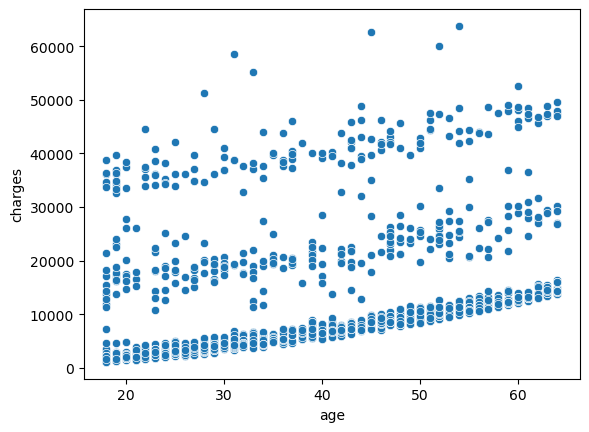

In [15]:
# scatter plot of age vs. charges
sns.scatterplot(x='age', y='charges', data=data)

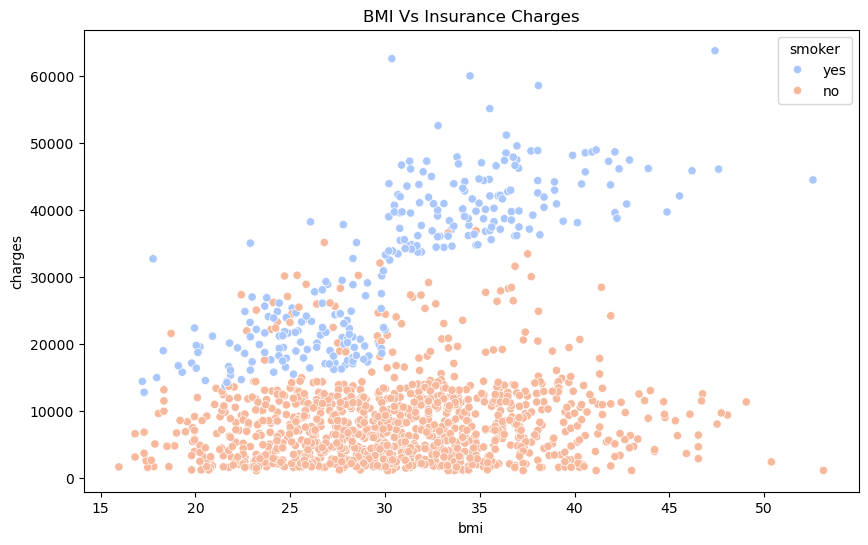

In [16]:
# Question: Does having a high BMI cost more? Does smoking make it worse?
plt.figure(figsize=(10,6))
sns.scatterplot(x='bmi',y='charges',hue='smoker',data=data,palette='coolwarm')
plt.title('BMI Vs Insurance Charges')
plt.xlabel('bmi')
plt.ylabel('charges')
plt.show()

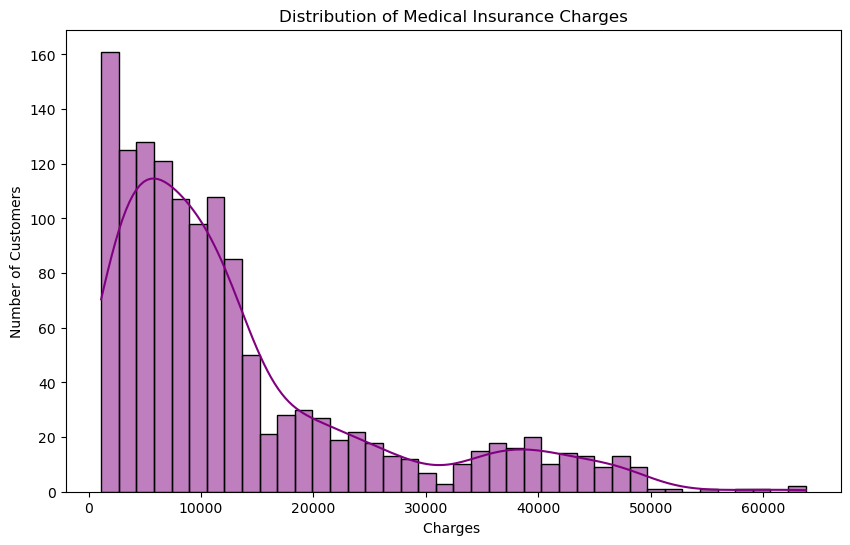

In [17]:
# Question: What is the most common insurance charge?
plt.figure(figsize=(10, 6))
sns.histplot(data['charges'], bins=40, kde=True, color='purple')
plt.title('Distribution of Medical Insurance Charges')
plt.xlabel('Charges ')
plt.ylabel('Number of Customers')
plt.show()

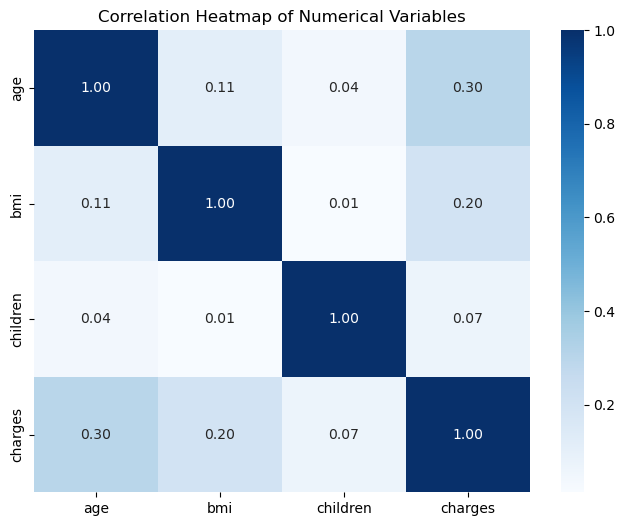

In [18]:
# Question: which numerical features are most closely tied to charges?
plt.figure(figsize=(8, 6))
# We only select numerical columns for the heatmap
numerical_df = data[['age', 'bmi', 'children', 'charges']]
sns.heatmap(numerical_df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### -> Data Engineering and Pipeline

In [19]:
x=data.drop('charges',axis=1)
y=data['charges']

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.3, random_state=1)

In [32]:
x_train.shape,y_train.shape

((935, 6), (935,))

In [33]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [34]:
# 1.  Create BMI Category

def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi <= 24.9:
        return 'Normal'
    elif 25.0 <= bmi <= 29.9:
        return 'Overweight'
    else:
        return 'Obese'

# Apply the function to create a new column
data['BMI_Category'] = data['bmi'].apply(categorize_bmi)

In [35]:
data['BMI_Category']

0       Overweight
1            Obese
2            Obese
3           Normal
4       Overweight
           ...    
1333         Obese
1334         Obese
1335         Obese
1336    Overweight
1337    Overweight
Name: BMI_Category, Length: 1337, dtype: object

In [36]:
data

,age,sex,bmi,children,smoker,region,charges,BMI_Category
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,Obese
1334,18,female,31.920,0,no,northeast,2205.98080,Obese
1335,18,female,36.850,0,no,southeast,1629.83350,Obese
1336,21,female,25.800,0,no,southwest,2007.94500,Overweight


In [45]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


#  Build the Pipeline Preprocessor
numerical_cols = ['age', 'bmi', 'children']
categorical_cols = ['sex', 'smoker', 'region', 'BMI_Category']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])


In [46]:
#  DATA ENGINEERING & MODEL TRAINING
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [47]:
# 1. BMI Category Banane ka function
def categorize_bmi(bmi):
    if bmi < 18.5: return 'Underweight'
    elif 18.5 <= bmi <= 24.9: return 'Normal'
    elif 25.0 <= bmi <= 29.9: return 'Overweight'
    else: return 'Obese'

# Data mein BMI_Category add karna
data['BMI_Category'] = data['bmi'].apply(categorize_bmi)

# 2. X aur y ko alag karna
X = data.drop('charges', axis=1)
y = data['charges']

# Training (80%) aur Testing (20%) data split karna
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#   PREPROCESSOR 
numerical_cols = ['age', 'bmi', 'children']
categorical_cols = ['sex', 'smoker', 'region', 'BMI_Category']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

#   PIPELINE 
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('regressor', LinearRegression())
])

# 5. Model Train Test 
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

#  Results calculate 
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("🎉 MODEL TRAINING COMPLETE! 🎉\n")
print("--- Final Model Performance ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

🎉 MODEL TRAINING COMPLETE! 🎉

--- Final Model Performance ---
Mean Absolute Error (MAE): $4,369.76
Root Mean Squared Error (RMSE): $6,033.27
R-squared (R2) Score: 0.8019
